In [ ]:
# !wget http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv

--2026-06-10 15:29:15--  http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv
Connecting to 26.165.184.44:8080... connected.
Proxy request sent, awaiting response... 200 OK
Length: 7877383 (7.5M) [text/csv]
Saving to: ‘ecg.csv’

ecg.csv             100%[===================>]   7.51M  2.63MB/s    in 2.9s    

2026-06-10 15:29:23 (2.63 MB/s) - ‘ecg.csv’ saved [7877383/7877383]



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Input
from keras.optimizers import AdamW
from keras.losses import MeanSquaredError
from keras.models import Sequential

I0000 00:00:1781189469.715921    1946 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781189470.265926    1946 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781189472.680686    1946 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df = pd.read_csv("/mnt/e/Deep Learning/data/ecg.csv")

In [3]:
df.head()

,-0.11252183,-2.8272038,-3.7738969,-4.3497511,-4.376041,-3.4749863,-2.1814082,-1.8182865,-1.2505219,-0.47749208,...,0.79216787,0.93354122,0.79695779,0.57862066,0.2577399,0.22807718,0.12343082,0.92528624,0.19313742,1.0
0,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
1,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
2,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
3,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0
4,-1.507674,-3.574550,-4.478011,-4.408275,-3.321242,-2.105171,-1.481048,-1.301362,-0.498240,-0.286928,...,1.089068,0.983369,1.014124,0.952629,0.749326,1.007076,1.634990,1.493365,-0.783134,1.0


In [4]:
df_array = df.values
print(df_array.shape)

labels = df_array[:, -1]
data = df_array[:, :-1]

print(f"Number of samples: {data.shape[0]}")
print(f"Number of poins: {data.shape[1]}")

(4997, 141)
Number of samples: 4997
Number of poins: 140


In [5]:
# labels
set(labels)

{np.float64(0.0), np.float64(1.0)}

In [6]:
train_df, test_df, train_label, test_label = train_test_split(data, labels, test_size=0.2, random_state=42)

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
print("train_label shape:", train_label.shape)
print("test_label shape:", test_label.shape)

train_df shape: (3997, 140)
test_df shape: (1000, 140)
train_label shape: (3997,)
test_label shape: (1000,)


0.0


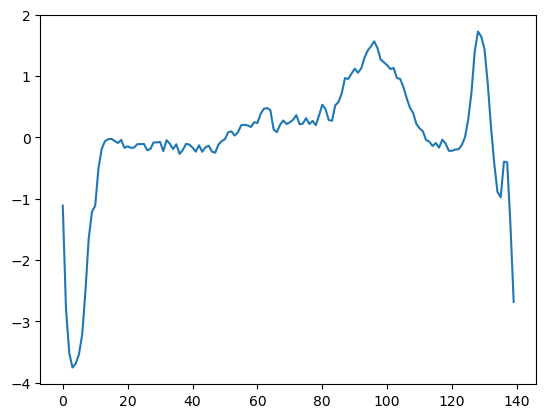

In [7]:
plt.plot(train_df[0, :])
print(train_label[0])

In [8]:
min_max_sc = MinMaxScaler()

train_data = min_max_sc.fit_transform(train_df)
test_data = min_max_sc.transform(test_df)

print("Mean:", train_data.mean())
print("Std :", train_data.std())
print("Min :", train_data.min())
print("Max :", train_data.max())

Mean: 0.6069777646177235
Std : 0.14067342717860384
Min : 0.0
Max : 1.0000000000000002


In [9]:
X_train = tf.convert_to_tensor(train_data, dtype=tf.float32)
X_test = tf.convert_to_tensor(test_data, dtype=tf.float32)

y_train = tf.convert_to_tensor(train_label, dtype=tf.float32)
y_test = tf.convert_to_tensor(test_label, dtype=tf.float32)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

print(X_train.dtype)
print(y_train.dtype)

(3997, 140)
(1000, 140)
(3997,)
(1000,)
<dtype: 'float32'>
<dtype: 'float32'>


W0000 00:00:1781189484.945329    1946 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [10]:
# Normal samples
X_train_normal = X_train[y_train == 1.0]
X_test_normal = X_test[y_test == 1.0]

# Abnormal samples
X_train_abnormal = X_train[y_train != 1.0]
X_test_abnormal = X_test[y_test != 1.0]

# Shapes
print("X_train_normal   :", X_train_normal.shape)
print("X_train_abnormal :", X_train_abnormal.shape)

print("X_test_normal    :", X_test_normal.shape)
print("X_test_abnormal  :", X_test_abnormal.shape)

X_train_normal   : (2328, 140)
X_train_abnormal : (1669, 140)
X_test_normal    : (590, 140)
X_test_abnormal  : (410, 140)


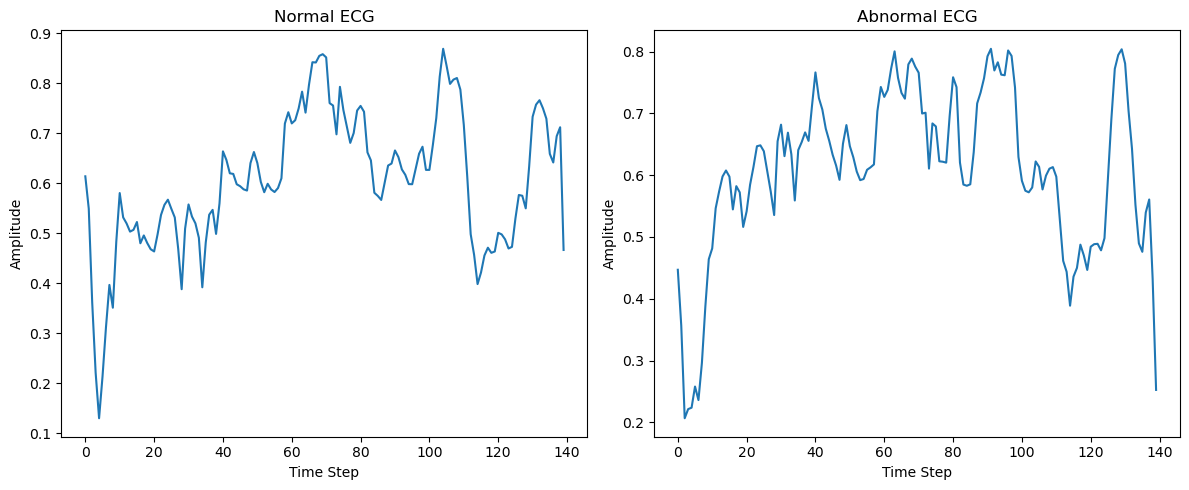

In [11]:
import matplotlib.pyplot as plt
import numpy as np

normal_sample = X_train_normal[0]
abnormal_sample = X_train_abnormal[0]

if hasattr(normal_sample, "numpy"):
    normal_sample = normal_sample.numpy()

if hasattr(abnormal_sample, "numpy"):
    abnormal_sample = abnormal_sample.numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(normal_sample)
plt.title("Normal ECG")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
plt.plot(abnormal_sample)
plt.title("Abnormal ECG")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [12]:
class AutoEncoder(keras.Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim

        self.encoder = Sequential(
            [
                Input(shape=(140, )),
                Dense(64, activation='relu'),
                Dense(32, activation='relu'),
                Dense(latent_dim, activation='relu')
            ]
        )

        self.decoder = Sequential(
            [
                Dense(32, activation='relu'),
                Dense(64, activation='relu'),
                Dense(140, activation='sigmoid')   
            ]
        )

    def call(self, inputs):
        encoder = self.encoder(inputs)
        decoder = self.decoder(encoder)

        return decoder

In [13]:
model = AutoEncoder(8)

In [14]:
model(tf.reshape(X_train_normal[0], shape=(-1, 140)))

<tf.Tensor: shape=(1, 140), dtype=float32, numpy=
array([[0.4865067 , 0.51080394, 0.50547695, 0.49411967, 0.51112777,
        0.49990726, 0.51188254, 0.49982557, 0.5049603 , 0.49427164,
        0.48756015, 0.5044731 , 0.50390464, 0.50467646, 0.5160126 ,
        0.49248463, 0.5036614 , 0.4910078 , 0.5056092 , 0.52193564,
        0.5374344 , 0.49938267, 0.4951277 , 0.50480676, 0.49837452,
        0.5045093 , 0.5139515 , 0.50143623, 0.49884322, 0.5166602 ,
        0.5002634 , 0.49561667, 0.48752284, 0.497913  , 0.5213967 ,
        0.5206573 , 0.50584495, 0.5039549 , 0.5068052 , 0.50369024,
        0.48435426, 0.48754638, 0.52983433, 0.5062951 , 0.49765995,
        0.5012485 , 0.47718716, 0.5057398 , 0.5002503 , 0.4890172 ,
        0.5145208 , 0.4958217 , 0.48155594, 0.48646644, 0.50431144,
        0.49381697, 0.48300824, 0.5051622 , 0.5019823 , 0.49995774,
        0.4923855 , 0.49307355, 0.51297563, 0.5005867 , 0.5025164 ,
        0.5094143 , 0.5025033 , 0.48161122, 0.49445474, 0.5038123 

In [15]:
model.summary()

Model: "auto_encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 8)              │        11,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (1, 140)               │        11,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,868 (89.33 KB)

 Trainable params: 22,868 (89.33 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer=AdamW(learning_rate=0.001),
              loss=MeanSquaredError)

In [17]:
history = model.fit(X_train_normal, X_train_normal, batch_size=32, epochs=30, validation_split=0.2)

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0135 - val_loss: 0.0049
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0052 - val_loss: 0.0045
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041 - val_loss: 0.0034
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0034 - val_loss: 0.0031
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - val_loss: 0.0028
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 9/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 10/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027 - val_loss: 0.0025
Epoch 11/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027 - val_loss: 0.0024
Epoch 12/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - val_lo

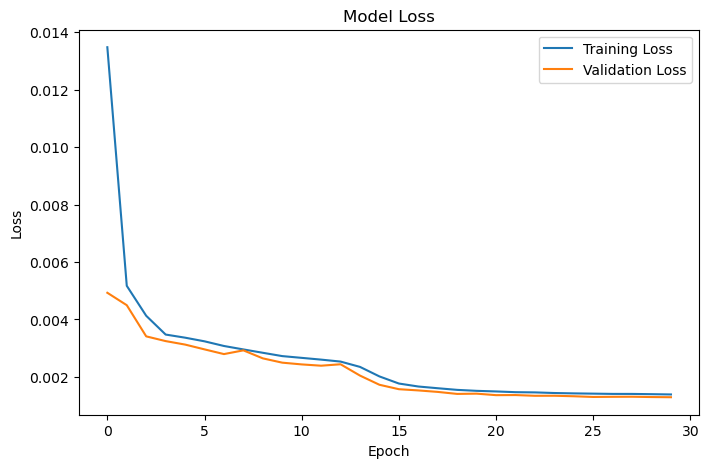

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [20]:
predicted_train_normal = model.predict(X_train_normal)

73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [29]:
mae = tf.keras.losses.mae(predicted_train_normal, X_train_normal)
mean_mae = tf.reduce_mean(mae)
std_mae = np.std(mae)

print(f"Mean of MAE Errors is: {mean_mae}")
print(f"STD of MAE Error is: {std_mae}")

Mean of MAE Errors is: 0.02445841208100319
STD of MAE Error is: 0.011017313227057457


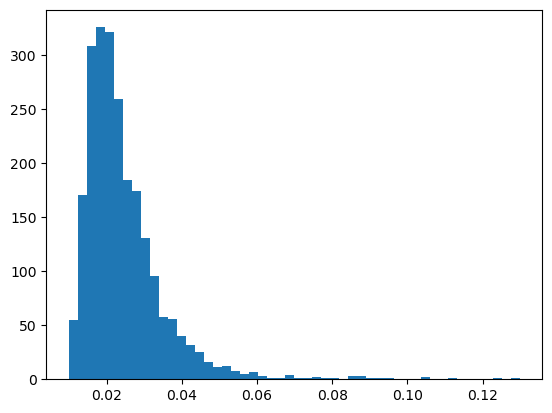

In [28]:
plt.hist(mae, bins=50);

In [31]:
thresh = mean_mae + std_mae
print(thresh)

tf.Tensor(0.035475723, shape=(), dtype=float32)


In [32]:
X_test.shape

TensorShape([1000, 140])

In [34]:
X_test_abnormal.shape

TensorShape([410, 140])

In [35]:
X_test_normal.shape

TensorShape([590, 140])

In [36]:
predict_test_data = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
mae_test_data = tf.keras.losses.mae(predict_test_data, X_test)

In [40]:
predict_test_data.shape

(1000, 140)

In [41]:
mae_test_data.shape

TensorShape([1000])

In [43]:
mae_test_array = mae_test_data.numpy()
predicted_test_labels = np.where(mae_test_data > thresh, 0, 1)

In [48]:
np.mean(predicted_test_labels == y_test.numpy())

np.float64(0.929)